In [4]:
from utils import load_or_fetch
from plot_setup import setup_chinese_font
import numpy as np
import pandas as pd

setup_chinese_font()

START = "2024-01-01"
END = "2024-12-31"

stocks = {
    "招商银行":  "sh.600036",
    "平安银行":  "sz.000001",
    "贵州茅台":  "sh.600519",
    "工商银行": "sh.601398",
    "山西汾酒": "sh.600809",
    "浙江震元":  "sz.000705"

}

# Pull data once; will be cached on disk after the first run.
data = {name: load_or_fetch(code, START, END) for name, code in stocks.items()}

# Log returns. You use log returns throughout Phase 2 for the reasons
# you documented in P1: additive over time, better-behaved for stats work.
returns = pd.DataFrame({
    name: np.log(df["close"] / df["close"].shift(1))
    for name, df in data.items()
}).dropna()

print(f"returns shape: {returns.shape}")
print(returns.head())

login success!
logout success!
login success!
logout success!
returns shape: (241, 6)
                招商银行      平安银行      贵州茅台      工商银行      山西汾酒      浙江震元
date                                                                  
2024-01-03  0.006865 -0.001086  0.005321  0.010384 -0.003252  0.023573
2024-01-04  0.001439 -0.009831 -0.014868  0.010278 -0.016281 -0.064777
2024-01-05  0.017113  0.017411 -0.003385 -0.004098 -0.010538  0.019878
2024-01-08 -0.005672 -0.013030 -0.011713  0.002051 -0.007977  0.037706
2024-01-09  0.001421  0.003273 -0.001820  0.000000 -0.011778 -0.034898


In [2]:
x = returns["招商银行"]
y = returns["平安银行"]

# Step 1: centre. Subtract each series' mean.
x_centered = x - x.mean()
y_centered = y - y.mean()

# Step 2: multiply day by day. Positive if both above-avg or both below-avg;
# negative if on opposite sides of their means.
products = x_centered * y_centered

# Step 3: average. This is the covariance.
covariance = products.mean()

# Step 4: normalise by the product of standard deviations.
correlation_manual = covariance / (x.std(ddof=0) * y.std(ddof=0))

print(f"Covariance:   {covariance:.6f}")
print(f"Correlation:  {correlation_manual:.4f}")

Covariance:   0.000207
Correlation:  0.8151


In [3]:
pairs = [
    ("招商银行", "平安银行"),
    ("招商银行", "贵州茅台"),
    ("招商银行", "浙江震元"),
]

for a, b in pairs:
    rho = returns[a].corr(returns[b])
    print(f"{a} × {b}:  ρ = {rho:+.4f}")

招商银行 × 平安银行:  ρ = +0.8151
招商银行 × 贵州茅台:  ρ = +0.5645
招商银行 × 浙江震元:  ρ = +0.1712


In [5]:
# Extend the basket with the two new names. load_or_fetch will pull and
# cache the new two; the four from earlier are already on disk.
stocks_six = {
    "招商银行":  "sh.600036",
    "平安银行":  "sz.000001",
    "工商银行":  "sh.601398",
    "贵州茅台":  "sh.600519",
    "山西汾酒":  "sh.600809",
    "浙江震元":  "sz.000705",
}

data_six = {name: load_or_fetch(code, START, END) for name, code in stocks_six.items()}

returns_six = pd.DataFrame({
    name: np.log(df["close"] / df["close"].shift(1))
    for name, df in data_six.items()
}).dropna()

corr = returns_six.corr()
print(corr.round(3))

       招商银行   平安银行   工商银行   贵州茅台   山西汾酒   浙江震元
招商银行  1.000  0.815  0.537  0.565  0.520  0.171
平安银行  0.815  1.000  0.455  0.588  0.575  0.293
工商银行  0.537  0.455  1.000  0.195  0.097 -0.090
贵州茅台  0.565  0.588  0.195  1.000  0.819  0.228
山西汾酒  0.520  0.575  0.097  0.819  1.000  0.224
浙江震元  0.171  0.293 -0.090  0.228  0.224  1.000


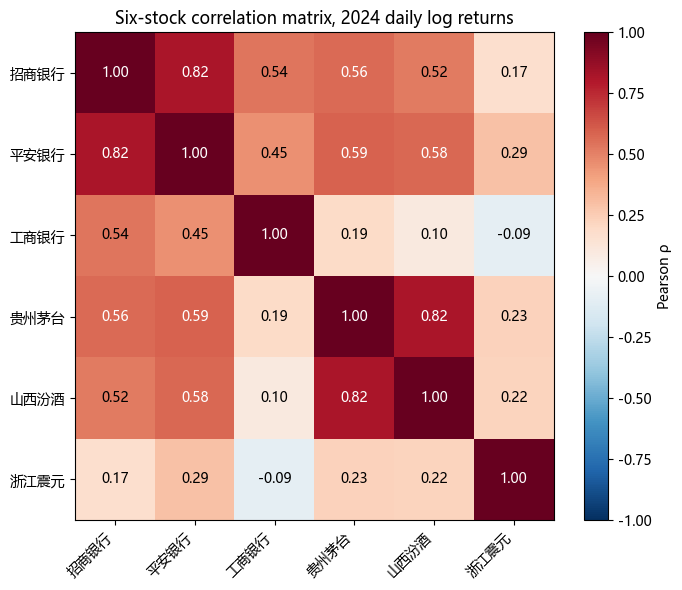

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

# Annotate every cell with the correlation value.
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        # Switch text colour on saturated cells so it stays readable.
        text_color = "white" if abs(val) > 0.55 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=text_color, fontsize=10)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
plt.colorbar(im, ax=ax, label="Pearson ρ")
ax.set_title("Six-stock correlation matrix, 2024 daily log returns")
plt.tight_layout()
plt.show()

In [7]:
# Quick visual check on 工商银行 × 浙江震元
ret_icbc = returns_six["工商银行"]
ret_zhenyuan = returns_six["浙江震元"]

# Split 工商 days into "up days" and "down days"
icbc_up = ret_icbc > 0
icbc_down = ret_icbc < 0

print(f"Mean 震元 return on 工商 up-days:   {ret_zhenyuan[icbc_up].mean()*100:+.3f}%")
print(f"Mean 震元 return on 工商 down-days: {ret_zhenyuan[icbc_down].mean()*100:+.3f}%")
print(f"Median 震元 return on 工商 up-days:   {ret_zhenyuan[icbc_up].median()*100:+.3f}%")
print(f"Median 震元 return on 工商 down-days: {ret_zhenyuan[icbc_down].median()*100:+.3f}%")

Mean 震元 return on 工商 up-days:   -0.272%
Mean 震元 return on 工商 down-days: +0.221%
Median 震元 return on 工商 up-days:   -0.317%
Median 震元 return on 工商 down-days: +0.485%


In [8]:
# Pearson vs Spearman for the full six-stock basket
corr_pearson = returns_six.corr(method="pearson")
corr_spearman = returns_six.corr(method="spearman")

# Just look at the difference
diff = corr_spearman - corr_pearson
print("Spearman − Pearson (positive = Spearman sees more co-movement):")
print(diff.round(3))

Spearman − Pearson (positive = Spearman sees more co-movement):
       招商银行   平安银行   工商银行   贵州茅台   山西汾酒   浙江震元
招商银行  0.000 -0.045  0.038 -0.079 -0.153 -0.074
平安银行 -0.045  0.000  0.081 -0.092 -0.153 -0.050
工商银行  0.038  0.081  0.000 -0.009  0.006  0.002
贵州茅台 -0.079 -0.092 -0.009  0.000 -0.115 -0.026
山西汾酒 -0.153 -0.153  0.006 -0.115  0.000 -0.029
浙江震元 -0.074 -0.050  0.002 -0.026 -0.029  0.000


In [9]:
p = returns_six["工商银行"].corr(returns_six["浙江震元"], method="pearson")
s = returns_six["工商银行"].corr(returns_six["浙江震元"], method="spearman")
print(f"工商 × 震元  Pearson:  {p:+.4f}")
print(f"工商 × 震元  Spearman: {s:+.4f}")
print(f"Difference (S − P):    {s - p:+.4f}")

工商 × 震元  Pearson:  -0.0899
工商 × 震元  Spearman: -0.0877
Difference (S − P):    +0.0022


In [11]:
s = returns_six["工商银行"].corr(returns_six["浙江震元"], method="spearman")
print(s)

-0.0876913084051087


In [12]:
# Use the six-stock basket we already have
# data_six is already loaded with OHLCV for each stock

vol_signal_results = {}

for name, df in data_six.items():
    # Volume ratio: today / trailing 20-day average
    vol_ratio = df["volume"] / df["volume"].rolling(window=20).mean()

    # Today's log return (for reference) and tomorrow's log return (the target)
    log_ret = np.log(df["close"] / df["close"].shift(1))
    next_day_ret = log_ret.shift(-1)  # shift -1 moves t+1 into row t

    # Align and drop NaN (first 20 rows from rolling, last row from shift)
    combined = pd.DataFrame({
        "vol_ratio": vol_ratio,
        "next_ret": next_day_ret,
    }).dropna()

    pearson = combined["vol_ratio"].corr(combined["next_ret"], method="pearson")
    spearman = combined["vol_ratio"].corr(combined["next_ret"], method="spearman")

    vol_signal_results[name] = {
        "pearson": pearson,
        "spearman": spearman,
        "n": len(combined),
    }

results_df = pd.DataFrame(vol_signal_results).T
print(results_df.round(4))

      pearson  spearman      n
招商银行   0.0532    0.0136  222.0
平安银行   0.0935    0.0369  222.0
工商银行  -0.1059   -0.0311  222.0
贵州茅台   0.0341   -0.0013  222.0
山西汾酒   0.0606    0.1200  222.0
浙江震元   0.1184    0.1194  222.0
